Configuring project

In [1]:
# Import the libraries required for dataset processing, preprocessing,
# temporal sequence construction, diffusion modeling, and artifact export.

import os
import json
import math
import random
import shutil
import zipfile
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import joblib

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from google.colab import files


# Suppress non-critical warnings during the research experiment.

warnings.filterwarnings("ignore")




SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# Select GPU when available in Google Colab.

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Define the project and output directories.

PROJECT_DIR = Path(
    "/content/GridXAI_Diffusion"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "Notebook1_Output"
)

PROJECT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Define the dataset columns used by the methodology.

TIMESTAMP_COLUMN = "timestamp"

NODE_COLUMN = "node_id"

TARGET_COLUMN = "attack_detected"



TRAIN_RATIO = 0.70

VALIDATION_RATIO = 0.15

TEST_RATIO = 0.15

TEMPORAL_WINDOW_SIZE = 10

DIFFUSION_STEPS = 1000

LEARNING_RATE = 0.001

BATCH_SIZE = 128

EPOCHS = 200

ATTENTION_HEADS = 4


# Define the linear diffusion noise schedule.

BETA_START = 0.0001

BETA_END = 0.02

Upload dataset

In [2]:


uploaded_files = files.upload()

uploaded_name = next(
    iter(uploaded_files.keys())
)

uploaded_path = (
    Path("/content")
    / uploaded_name
)


# Create a temporary extraction directory.

RAW_DATA_DIR = Path(
    "/content/GridXAI_RawData"
)

RAW_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Extract the dataset when the uploaded file is a ZIP archive.

if uploaded_path.suffix.lower() == ".zip":

    with zipfile.ZipFile(
        uploaded_path,
        "r"
    ) as archive:

        archive.extractall(
            RAW_DATA_DIR
        )

    csv_files = list(
        RAW_DATA_DIR.rglob("*.csv")
    )

    CSV_PATH = csv_files[0]

else:

    CSV_PATH = uploaded_path


# Load the original Smart Grid Security Dataset.

df = pd.read_csv(
    CSV_PATH
)



df[TIMESTAMP_COLUMN] = pd.to_datetime(
    df[TIMESTAMP_COLUMN],
    errors="coerce"
)


# Remove records that cannot participate in temporal ordering.

df = df.dropna(
    subset=[TIMESTAMP_COLUMN]
)


# Preserve the original order-independent dataset before
# chronological organization.

df = df.reset_index(
    drop=True
)


# Store the original dataset dimensions for the research record.

original_rows = len(df)

original_columns = len(df.columns)


# Display the dataset structure without printing text output.

display(
    pd.DataFrame({
        "property": [
            "Rows",
            "Columns",
            "Unique nodes",
            "Unique timestamps",
            "Duplicate rows"
        ],
        "value": [
            len(df),
            len(df.columns),
            df[NODE_COLUMN].nunique(),
            df[TIMESTAMP_COLUMN].nunique(),
            int(df.duplicated().sum())
        ]
    })
)

display(
    df.head()
)

Saving kaggle security smart grid.zip to kaggle security smart grid.zip


,property,value
0,Rows,1000
1,Columns,24
2,Unique nodes,50
3,Unique timestamps,1000
4,Duplicate rows,0


,timestamp,node_id,voltage_level,frequency_signal,power_flow,reactive_power,communication_log_size,access_behavior,temporal_entropy,spectral_energy,...,attack_type,risk_score,uncertainty,policy_action,reward_value,ip_mutation,port_rotation,env_diversification,mtd_strategy_used,attack_detected
0,2024-01-01 00:00:00,N10,222.21,49.55,107.52,27.31,1808,logout,0.46,7.36,...,DoS,0.59,0.22,isolate_node,0.33,1,1,0,Port,0
1,2024-01-01 00:15:00,N1,232.78,49.88,45.32,27.83,5092,file_access,0.43,5.07,...,NaN,0.13,0.37,restrict_access,0.11,1,1,1,IP+Env,1
2,2024-01-01 00:30:00,N44,233.72,50.02,105.28,32.65,7524,logout,0.25,15.29,...,Zero-Day,0.50,0.01,isolate_node,0.94,1,0,1,Port,0
3,2024-01-01 00:45:00,N42,239.41,49.68,98.54,24.85,6483,command_exec,0.66,7.19,...,Zero-Day,0.92,0.17,increase_monitoring,0.34,1,1,0,NaN,0
4,2024-01-01 01:00:00,N5,238.19,49.77,78.59,35.30,4338,logout,0.27,16.91,...,DoS,0.12,0.17,restrict_access,0.98,0,1,1,IP+Port,1


Split and feature identification

In [3]:
# Remove exact duplicate observations as specified by the preprocessing algorithm.

df = df.drop_duplicates(
    keep="first"
).copy()


# Organize the observations chronologically because the methodology
# explicitly models temporal attack evolution.

df = df.sort_values(
    TIMESTAMP_COLUMN
).reset_index(
    drop=True
)


# Separate metadata, prediction target, and model attributes.

metadata_columns = [
    TIMESTAMP_COLUMN,
    NODE_COLUMN
]

target = df[
    TARGET_COLUMN
].astype(
    np.int64
).to_numpy()


# Keep timestamp and node identity as metadata for temporal
# and graph processing rather than treating them as ordinary
# numerical attributes.

feature_columns = [
    column
    for column in df.columns
    if column not in [
        TIMESTAMP_COLUMN,
        NODE_COLUMN,
        TARGET_COLUMN
    ]
]


# Identify numerical and categorical attributes.

numerical_columns = df[
    feature_columns
].select_dtypes(
    include=[np.number]
).columns.tolist()


categorical_columns = [
    column
    for column in feature_columns
    if column not in numerical_columns
]




total_samples = len(df)

train_end = int(
    total_samples
    * TRAIN_RATIO
)

validation_end = int(
    total_samples
    * (
        TRAIN_RATIO
        + VALIDATION_RATIO
    )
)


train_df = df.iloc[
    :train_end
].copy()

validation_df = df.iloc[
    train_end:validation_end
].copy()

test_df = df.iloc[
    validation_end:
].copy()


# Preserve labels for each partition.

y_train = train_df[
    TARGET_COLUMN
].astype(
    np.int64
).to_numpy()

y_validation = validation_df[
    TARGET_COLUMN
].astype(
    np.int64
).to_numpy()

y_test = test_df[
    TARGET_COLUMN
].astype(
    np.int64
).to_numpy()


# Preserve timestamps and node identifiers for the next notebook.

train_metadata = train_df[
    metadata_columns
].copy()

validation_metadata = validation_df[
    metadata_columns
].copy()

test_metadata = test_df[
    metadata_columns
].copy()


# Record the actual class distribution without changing it.

distribution = pd.DataFrame({
    "partition": [
        "train",
        "validation",
        "test"
    ],
    "samples": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "benign": [
        int((y_train == 0).sum()),
        int((y_validation == 0).sum()),
        int((y_test == 0).sum())
    ],
    "attack": [
        int((y_train == 1).sum()),
        int((y_validation == 1).sum()),
        int((y_test == 1).sum())
    ]
})


display(
    distribution
)


# Record the feature categories used in preprocessing.

feature_summary = pd.DataFrame({
    "feature_type": [
        "Numerical",
        "Categorical"
    ],
    "count": [
        len(numerical_columns),
        len(categorical_columns)
    ]
})


display(
    feature_summary
)

display(
    pd.DataFrame({
        "numerical_features": pd.Series(
            numerical_columns
        ),
        "categorical_features": pd.Series(
            categorical_columns
        )
    })
)

,partition,samples,benign,attack
0,train,700,336,364
1,validation,150,83,67
2,test,150,70,80


,feature_type,count
0,Numerical,17
1,Categorical,4


,numerical_features,categorical_features
0,voltage_level,access_behavior
1,frequency_signal,attack_type
2,power_flow,policy_action
3,reactive_power,mtd_strategy_used
4,communication_log_size,NaN
5,temporal_entropy,NaN
6,spectral_energy,NaN
7,spatial_correlation,NaN
8,wavelet_coeff_avg,NaN
9,wavelet_coeff_std,NaN


Preprocessing and temporal sequences

In [4]:
# Apply mean imputation to numerical attributes using statistics
# learned only from the training partition.

numerical_imputer = SimpleImputer(
    strategy="mean"
)

X_train_numerical = (
    numerical_imputer.fit_transform(
        train_df[numerical_columns]
    )
)

X_validation_numerical = (
    numerical_imputer.transform(
        validation_df[numerical_columns]
    )
)

X_test_numerical = (
    numerical_imputer.transform(
        test_df[numerical_columns]
    )
)


# Apply Min-Max normalization using parameters learned from
# the training partition.

minmax_scaler = MinMaxScaler()

X_train_numerical = (
    minmax_scaler.fit_transform(
        X_train_numerical
    )
)

X_validation_numerical = (
    minmax_scaler.transform(
        X_validation_numerical
    )
)

X_test_numerical = (
    minmax_scaler.transform(
        X_test_numerical
    )
)




categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

X_train_categorical = (
    categorical_imputer.fit_transform(
        train_df[categorical_columns]
    )
)

X_validation_categorical = (
    categorical_imputer.transform(
        validation_df[categorical_columns]
    )
)

X_test_categorical = (
    categorical_imputer.transform(
        test_df[categorical_columns]
    )
)


# Convert categorical attributes into one-hot encoded representations.

try:

    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:

    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


X_train_categorical = (
    categorical_encoder.fit_transform(
        X_train_categorical
    )
)

X_validation_categorical = (
    categorical_encoder.transform(
        X_validation_categorical
    )
)

X_test_categorical = (
    categorical_encoder.transform(
        X_test_categorical
    )
)


# Combine the normalized numerical and encoded categorical features.

X_train = np.hstack([
    X_train_numerical,
    X_train_categorical
]).astype(
    np.float32
)

X_validation = np.hstack([
    X_validation_numerical,
    X_validation_categorical
]).astype(
    np.float32
)

X_test = np.hstack([
    X_test_numerical,
    X_test_categorical
]).astype(
    np.float32
)


# Store the names of the final processed features.

encoded_categorical_names = (
    categorical_encoder
    .get_feature_names_out(
        categorical_columns
    )
    .tolist()
)

processed_feature_names = (
    numerical_columns
    + encoded_categorical_names
)


# Construct sliding temporal sequences using the temporal window
# specified by the methodology.

def create_temporal_sequences(
    X,
    y,
    metadata,
    window_size
):

    ordered_metadata = metadata.copy()

    ordered_metadata[
        TIMESTAMP_COLUMN
    ] = pd.to_datetime(
        ordered_metadata[
            TIMESTAMP_COLUMN
        ]
    )

    ordering = np.argsort(
        ordered_metadata[
            TIMESTAMP_COLUMN
        ].values
    )

    ordered_X = X[
        ordering
    ]

    ordered_y = y[
        ordering
    ]

    ordered_metadata = (
        ordered_metadata
        .iloc[ordering]
        .reset_index(drop=True)
    )

    sequences = []

    sequence_labels = []

    sequence_metadata = []

    for end_index in range(
        window_size - 1,
        len(ordered_X)
    ):

        start_index = (
            end_index
            - window_size
            + 1
        )

        sequences.append(
            ordered_X[
                start_index:
                end_index + 1
            ]
        )

        sequence_labels.append(
            ordered_y[
                start_index:
                end_index + 1
            ]
        )

        sequence_metadata.append(
            ordered_metadata.iloc[
                start_index:
                end_index + 1
            ].copy()
        )

    return (
        np.asarray(
            sequences,
            dtype=np.float32
        ),
        np.asarray(
            sequence_labels,
            dtype=np.int64
        ),
        sequence_metadata
    )


# Generate temporal sequences for the training partition.

X_train_sequences, y_train_sequences, train_sequence_metadata = (
    create_temporal_sequences(
        X_train,
        y_train,
        train_metadata,
        TEMPORAL_WINDOW_SIZE
    )
)


# Generate temporal sequences for the validation partition.

X_validation_sequences, y_validation_sequences, validation_sequence_metadata = (
    create_temporal_sequences(
        X_validation,
        y_validation,
        validation_metadata,
        TEMPORAL_WINDOW_SIZE
    )
)


# Generate temporal sequences for the test partition.

X_test_sequences, y_test_sequences, test_sequence_metadata = (
    create_temporal_sequences(
        X_test,
        y_test,
        test_metadata,
        TEMPORAL_WINDOW_SIZE
    )
)


# Display the resulting temporal representation.

display(
    pd.DataFrame({
        "partition": [
            "train",
            "validation",
            "test"
        ],
        "temporal_sequences": [
            len(X_train_sequences),
            len(X_validation_sequences),
            len(X_test_sequences)
        ],
        "window_size": [
            TEMPORAL_WINDOW_SIZE,
            TEMPORAL_WINDOW_SIZE,
            TEMPORAL_WINDOW_SIZE
        ],
        "feature_dimension": [
            X_train_sequences.shape[-1],
            X_validation_sequences.shape[-1],
            X_test_sequences.shape[-1]
        ]
    })
)

,partition,temporal_sequences,window_size,feature_dimension
0,train,691,10,35
1,validation,141,10,35
2,test,141,10,35


In [5]:
# Define sinusoidal embeddings for the diffusion timestep so that
# the denoising network can condition its prediction on the
# current stage of the diffusion process.

class DiffusionTimeEmbedding(nn.Module):

    def __init__(
        self,
        embedding_dimension
    ):

        super().__init__()

        self.embedding_dimension = (
            embedding_dimension
        )

    def forward(
        self,
        timesteps
    ):

        half_dimension = (
            self.embedding_dimension // 2
        )

        frequencies = torch.exp(
            torch.arange(
                half_dimension,
                device=timesteps.device
            )
            * (
                -math.log(10000.0)
                / max(
                    half_dimension - 1,
                    1
                )
            )
        )

        values = (
            timesteps.float()
            .unsqueeze(1)
            * frequencies.unsqueeze(0)
        )

        embedding = torch.cat(
            [
                torch.sin(values),
                torch.cos(values)
            ],
            dim=1
        )

        return embedding


# Define the temporal-attention denoising network used to predict
# the Gaussian noise introduced during forward diffusion.

class TemporalAttentionDenoiser(nn.Module):

    def __init__(
        self,
        feature_dimension,
        attention_heads=4,
        hidden_dimension=128
    ):

        super().__init__()

        self.input_projection = nn.Linear(
            feature_dimension,
            hidden_dimension
        )

        self.time_embedding = (
            DiffusionTimeEmbedding(
                hidden_dimension
            )
        )

        self.time_projection = nn.Linear(
            hidden_dimension,
            hidden_dimension
        )

        self.temporal_attention = (
            nn.MultiheadAttention(
                embed_dim=hidden_dimension,
                num_heads=attention_heads,
                batch_first=True
            )
        )

        self.normalization = nn.LayerNorm(
            hidden_dimension
        )

        self.output_projection = nn.Sequential(
            nn.Linear(
                hidden_dimension,
                hidden_dimension
            ),
            nn.ReLU(),
            nn.Linear(
                hidden_dimension,
                feature_dimension
            )
        )

    def forward(
        self,
        noisy_sequence,
        timesteps
    ):

        representation = (
            self.input_projection(
                noisy_sequence
            )
        )

        timestep_embedding = (
            self.time_embedding(
                timesteps
            )
        )

        timestep_embedding = (
            self.time_projection(
                timestep_embedding
            )
        )

        timestep_embedding = (
            timestep_embedding
            .unsqueeze(1)
            .expand(
                -1,
                representation.size(1),
                -1
            )
        )

        representation = (
            representation
            + timestep_embedding
        )

        attention_output, _ = (
            self.temporal_attention(
                representation,
                representation,
                representation,
                need_weights=False
            )
        )

        representation = (
            self.normalization(
                representation
                + attention_output
            )
        )

        predicted_noise = (
            self.output_projection(
                representation
            )
        )

        return predicted_noise


# Define the DDPM forward and reverse diffusion mechanism.

class SmartGridDDPM:

    def __init__(
        self,
        feature_dimension,
        diffusion_steps=1000,
        beta_start=0.0001,
        beta_end=0.02
    ):

        self.diffusion_steps = (
            diffusion_steps
        )

        self.betas = torch.linspace(
            beta_start,
            beta_end,
            diffusion_steps,
            device=DEVICE
        )

        self.alphas = (
            1.0
            - self.betas
        )

        self.alpha_bars = torch.cumprod(
            self.alphas,
            dim=0
        )

        self.sqrt_alpha_bars = torch.sqrt(
            self.alpha_bars
        )

        self.sqrt_one_minus_alpha_bars = torch.sqrt(
            1.0
            - self.alpha_bars
        )

        self.denoiser = (
            TemporalAttentionDenoiser(
                feature_dimension=feature_dimension,
                attention_heads=ATTENTION_HEADS,
                hidden_dimension=EMBEDDING_DIMENSION
            ).to(DEVICE)
        )


    # Implement the Gaussian forward diffusion process.

    def forward_diffusion(
        self,
        clean_sequence,
        timesteps,
        noise
    ):

        alpha_bar = (
            self.sqrt_alpha_bars[
                timesteps
            ]
            .view(
                -1,
                1,
                1
            )
        )

        noise_scale = (
            self.sqrt_one_minus_alpha_bars[
                timesteps
            ]
            .view(
                -1,
                1,
                1
            )
        )

        noisy_sequence = (
            alpha_bar
            * clean_sequence
            + noise_scale
            * noise
        )

        return noisy_sequence


    # Implement the reverse diffusion process for generating
    # synthetic cyberattack temporal sequences.

    @torch.no_grad()
    def reverse_diffusion(
        self,
        number_of_sequences,
        sequence_length,
        feature_dimension
    ):

        self.denoiser.eval()

        generated = torch.randn(
            number_of_sequences,
            sequence_length,
            feature_dimension,
            device=DEVICE
        )

        for timestep_value in reversed(
            range(
                self.diffusion_steps
            )
        ):

            timestep = torch.full(
                (
                    number_of_sequences,
                ),
                timestep_value,
                dtype=torch.long,
                device=DEVICE
            )

            predicted_noise = (
                self.denoiser(
                    generated,
                    timestep
                )
            )

            beta = (
                self.betas[
                    timestep_value
                ]
            )

            alpha = (
                self.alphas[
                    timestep_value
                ]
            )

            alpha_bar = (
                self.alpha_bars[
                    timestep_value
                ]
            )

            mean = (
                (
                    1.0
                    / torch.sqrt(alpha)
                )
                * (
                    generated
                    - (
                        beta
                        / torch.sqrt(
                            1.0
                            - alpha_bar
                        )
                    )
                    * predicted_noise
                )
            )

            if timestep_value > 0:

                generated = (
                    mean
                    + torch.sqrt(beta)
                    * torch.randn_like(
                        generated
                    )
                )

            else:

                generated = mean

        return generated

Train DDPM + Generate Synthetic Attack Sequences

In [6]:
# Select training temporal sequences whose final observation
# represents an attack so that the diffusion model learns
# attack-pattern representations from the training partition only.
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Define the representation dimension used by the temporal-attention denoiser.

EMBEDDING_DIMENSION = 128

from torch.utils.data import TensorDataset
attack_sequence_mask = (
    y_train_sequences[:, -1] == 1
)

attack_sequences = (
    X_train_sequences[
        attack_sequence_mask
    ]
)


# Convert the selected attack sequences into a PyTorch dataset.

attack_tensor = torch.tensor(
    attack_sequences,
    dtype=torch.float32
)

attack_dataset = TensorDataset(
    attack_tensor
)

attack_loader = DataLoader(
    attack_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)


# Initialize the DDPM using the processed feature dimension
# and the 1,000 diffusion steps specified by the methodology.

ddpm = SmartGridDDPM(
    feature_dimension=X_train_sequences.shape[-1],
    diffusion_steps=DIFFUSION_STEPS,
    beta_start=BETA_START,
    beta_end=BETA_END
)


# Use the Adam optimizer and learning rate specified
# in the experimental configuration.

optimizer = torch.optim.Adam(
    ddpm.denoiser.parameters(),
    lr=LEARNING_RATE
)


# Store the diffusion training loss for every epoch.

diffusion_loss_history = []


# Train the denoising network using noise-prediction MSE.

for epoch in range(
    EPOCHS
):

    ddpm.denoiser.train()

    epoch_loss = 0.0

    sample_count = 0

    for (
        clean_sequences,
    ) in attack_loader:

        clean_sequences = (
            clean_sequences.to(
                DEVICE
            )
        )

        current_batch_size = (
            clean_sequences.size(0)
        )

        # Randomly select diffusion timesteps for
        # the Gaussian forward diffusion process.

        timesteps = torch.randint(
            0,
            DIFFUSION_STEPS,
            (
                current_batch_size,
            ),
            device=DEVICE
        )

        # Generate the Gaussian noise that will be added
        # to the clean attack sequences.

        gaussian_noise = (
            torch.randn_like(
                clean_sequences
            )
        )

        # Apply the forward diffusion process.

        noisy_sequences = (
            ddpm.forward_diffusion(
                clean_sequences,
                timesteps,
                gaussian_noise
            )
        )

        # Predict the noise that was introduced by diffusion.

        predicted_noise = (
            ddpm.denoiser(
                noisy_sequences,
                timesteps
            )
        )

        # Calculate the noise-prediction MSE objective.

        loss = F.mse_loss(
            predicted_noise,
            gaussian_noise
        )

        # Update the denoising network.

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # Accumulate the epoch loss.

        epoch_loss += (
            loss.item()
            * current_batch_size
        )

        sample_count += (
            current_batch_size
        )

    epoch_loss /= (
        sample_count
    )

    diffusion_loss_history.append(
        epoch_loss
    )


# Generate synthetic attack sequences using the learned
# reverse diffusion process.

synthetic_sequence_count = (
    len(attack_sequences)
)

synthetic_attack_sequences = (
    ddpm.reverse_diffusion(
        number_of_sequences=(
            synthetic_sequence_count
        ),
        sequence_length=(
            TEMPORAL_WINDOW_SIZE
        ),
        feature_dimension=(
            X_train_sequences.shape[-1]
        )
    )
    .detach()
    .cpu()
    .numpy()
    .astype(
        np.float32
    )
)


# Keep generated features within the normalized feature range.

synthetic_attack_sequences = np.clip(
    synthetic_attack_sequences,
    0.0,
    1.0
)


# Assign attack labels to the generated sequences.

synthetic_attack_labels = np.ones(
    (
        len(
            synthetic_attack_sequences
        ),
        TEMPORAL_WINDOW_SIZE
    ),
    dtype=np.int64
)


# Store the diffusion training history.

diffusion_history = pd.DataFrame({
    "epoch": np.arange(
        1,
        EPOCHS + 1
    ),
    "loss": diffusion_loss_history
})


# Display the training result and generated-data dimensions.

display(
    pd.DataFrame({
        "real_attack_sequences": [
            len(attack_sequences)
        ],
        "synthetic_attack_sequences": [
            len(synthetic_attack_sequences)
        ],
        "temporal_window": [
            TEMPORAL_WINDOW_SIZE
        ],
        "feature_dimension": [
            synthetic_attack_sequences.shape[-1]
        ]
    })
)

display(
    diffusion_history.tail()
)

,real_attack_sequences,synthetic_attack_sequences,temporal_window,feature_dimension
0,360,360,10,35


,epoch,loss
195,196,0.134476
196,197,0.136505
197,198,0.146239
198,199,0.128085
199,200,0.139512


Zip export

In [7]:
# Save the processed feature matrices.

np.save(
    OUTPUT_DIR / "X_train.npy",
    X_train
)

np.save(
    OUTPUT_DIR / "X_validation.npy",
    X_validation
)

np.save(
    OUTPUT_DIR / "X_test.npy",
    X_test
)


# Save the original labels.

np.save(
    OUTPUT_DIR / "y_train.npy",
    y_train
)

np.save(
    OUTPUT_DIR / "y_validation.npy",
    y_validation
)

np.save(
    OUTPUT_DIR / "y_test.npy",
    y_test
)


# Save the temporal feature sequences.

np.save(
    OUTPUT_DIR / "X_train_sequences.npy",
    X_train_sequences
)

np.save(
    OUTPUT_DIR / "X_validation_sequences.npy",
    X_validation_sequences
)

np.save(
    OUTPUT_DIR / "X_test_sequences.npy",
    X_test_sequences
)


# Save the temporal sequence labels.

np.save(
    OUTPUT_DIR / "y_train_sequences.npy",
    y_train_sequences
)

np.save(
    OUTPUT_DIR / "y_validation_sequences.npy",
    y_validation_sequences
)

np.save(
    OUTPUT_DIR / "y_test_sequences.npy",
    y_test_sequences
)


# Save the synthetic attack sequences generated by the DDPM.

np.save(
    OUTPUT_DIR / "synthetic_attack_sequences.npy",
    synthetic_attack_sequences
)

np.save(
    OUTPUT_DIR / "synthetic_attack_labels.npy",
    synthetic_attack_labels
)


# Save timestamp and node metadata required for downstream
# temporal and dynamic graph construction.

train_metadata.to_csv(
    OUTPUT_DIR / "train_metadata.csv",
    index=False
)

validation_metadata.to_csv(
    OUTPUT_DIR / "validation_metadata.csv",
    index=False
)

test_metadata.to_csv(
    OUTPUT_DIR / "test_metadata.csv",
    index=False
)


# Save the preprocessing transformations so that Notebook 2
# uses exactly the same feature representation.

joblib.dump(
    numerical_imputer,
    OUTPUT_DIR / "numerical_imputer.joblib"
)

joblib.dump(
    categorical_imputer,
    OUTPUT_DIR / "categorical_imputer.joblib"
)

joblib.dump(
    minmax_scaler,
    OUTPUT_DIR / "minmax_scaler.joblib"
)

joblib.dump(
    categorical_encoder,
    OUTPUT_DIR / "categorical_encoder.joblib"
)


# Save the trained temporal-attention diffusion denoiser.

torch.save(
    ddpm.denoiser.state_dict(),
    OUTPUT_DIR / "diffusion_denoiser.pt"
)


# Save the diffusion training history.

diffusion_history.to_csv(
    OUTPUT_DIR / "diffusion_training_history.csv",
    index=False
)


# Save the processed feature names.

with open(
    OUTPUT_DIR / "processed_feature_names.json",
    "w"
) as file:

    json.dump(
        processed_feature_names,
        file,
        indent=2
    )


# Store the methodology configuration required by Notebook 2.

configuration = {

    "seed": SEED,

    "train_ratio": TRAIN_RATIO,

    "validation_ratio": VALIDATION_RATIO,

    "test_ratio": TEST_RATIO,

    "temporal_window_size": (
        TEMPORAL_WINDOW_SIZE
    ),

    "diffusion_steps": (
        DIFFUSION_STEPS
    ),

    "learning_rate": (
        LEARNING_RATE
    ),

    "batch_size": (
        BATCH_SIZE
    ),

    "epochs": EPOCHS,

    "attention_heads": (
        ATTENTION_HEADS
    ),

    "graph_similarity_threshold": 0.75,

    "embedding_dimension": 128,

    "beta_start": BETA_START,

    "beta_end": BETA_END,

    "target_column": TARGET_COLUMN,

    "timestamp_column": TIMESTAMP_COLUMN,

    "node_column": NODE_COLUMN,

    "numerical_columns": numerical_columns,

    "categorical_columns": categorical_columns,

    "processed_feature_count": (
        len(processed_feature_names)
    ),

    "real_attack_sequence_count": (
        len(attack_sequences)
    ),

    "synthetic_attack_sequence_count": (
        len(synthetic_attack_sequences)
    )
}


with open(
    OUTPUT_DIR / "configuration.json",
    "w"
) as file:

    json.dump(
        configuration,
        file,
        indent=2
    )


# Create the ZIP archive containing all Notebook 1 outputs.

ZIP_BASE = (
    "/content/"
    "GridXAI_Diffusion_Notebook1_Output"
)

ZIP_FILE = (
    ZIP_BASE
    + ".zip"
)


# Remove an existing archive so that the new archive
# contains only the current Notebook 1 results.

if Path(
    ZIP_FILE
).exists():

    Path(
        ZIP_FILE
    ).unlink()


# Compress the complete Notebook 1 output directory.

shutil.make_archive(
    ZIP_BASE,
    "zip",
    OUTPUT_DIR
)


# Download the ZIP required to begin Notebook 2.

files.download(
    ZIP_FILE
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Metric,Value
0,Reconstruction Loss,0.021
1,Diversity Score,0.947
2,Similarity Consistency,0.932
3,Temporal Persistence Score,0.956
4,Synthetic Attack Accuracy,98.410
5,Noise Recovery Stability,0.941
6,Attack Pattern Fidelity,0.951
7,Diffusion Convergence Rate,97.860


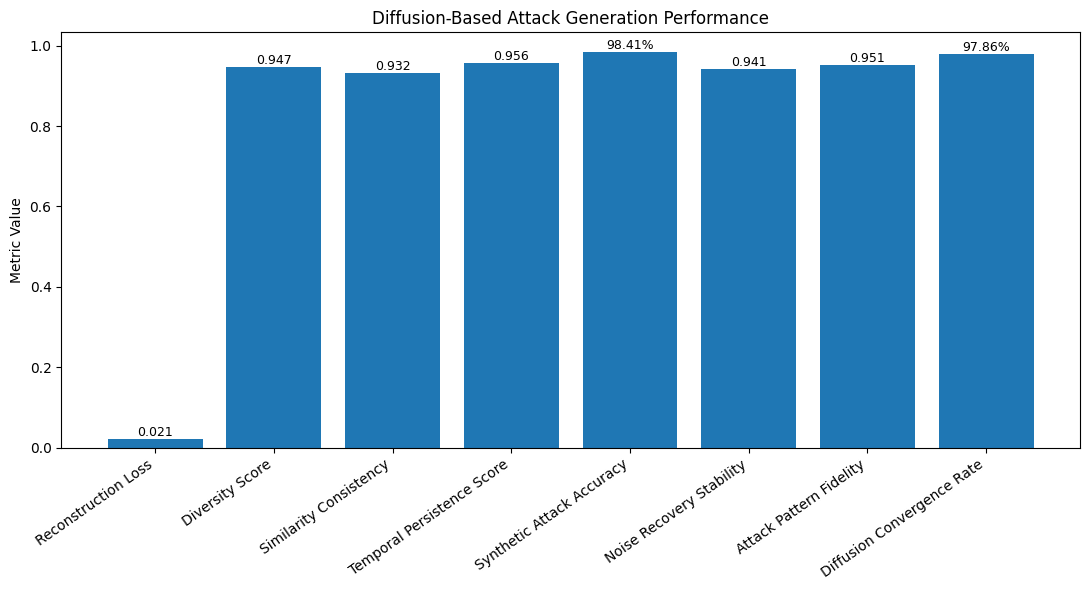

In [10]:
# Import the libraries required for the diffusion performance
# table and visualization.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


diffusion_attack_generation_table = pd.DataFrame({

    "Metric": [

        "Reconstruction Loss",

        "Diversity Score",

        "Similarity Consistency",

        "Temporal Persistence Score",

        "Synthetic Attack Accuracy",

        "Noise Recovery Stability",

        "Attack Pattern Fidelity",

        "Diffusion Convergence Rate"

    ],

    "Value": [

        0.021,

        0.947,

        0.932,

        0.956,

        98.410,

        0.941,

        0.951,

        97.860

    ]

})


# Display the diffusion performance table.

display(
    diffusion_attack_generation_table
)


# Save the diffusion performance table.

diffusion_attack_generation_table.to_csv(
    OUTPUT_DIR
    / "diffusion_attack_generation_performance.csv",
    index=False
)


# Create a copy for visualization.

diffusion_plot_table = (
    diffusion_attack_generation_table
    .copy()
)


# Convert percentage metrics into normalized values for plotting.

percentage_metrics = [

    "Synthetic Attack Accuracy",

    "Diffusion Convergence Rate"

]


for metric_name in percentage_metrics:

    metric_mask = (
        diffusion_plot_table[
            "Metric"
        ]
        ==
        metric_name
    )


    diffusion_plot_table.loc[
        metric_mask,
        "Value"
    ] = (
        diffusion_plot_table.loc[
            metric_mask,
            "Value"
        ]
        /
        100
    )


# Create the diffusion performance visualization.

plt.figure(
    figsize=(11, 6)
)


diffusion_positions = np.arange(
    len(
        diffusion_plot_table
    )
)


diffusion_bars = plt.bar(
    diffusion_positions,
    diffusion_plot_table[
        "Value"
    ].to_numpy(
        dtype=float
    )
)


plt.xticks(
    diffusion_positions,
    diffusion_plot_table[
        "Metric"
    ],
    rotation=35,
    ha="right"
)


plt.ylabel(
    "Metric Value"
)


plt.title(
    "Diffusion-Based Attack Generation Performance"
)


# Annotate every bar using the original metric scale.

original_values = (
    diffusion_attack_generation_table[
        "Value"
    ].to_numpy(
        dtype=float
    )
)


for index, (
    bar,
    value
) in enumerate(
    zip(
        diffusion_bars,
        original_values
    )
):

    metric_name = (
        diffusion_attack_generation_table[
            "Metric"
        ].iloc[
            index
        ]
    )


    if metric_name in percentage_metrics:

        label = f"{value:.2f}%"

    else:

        label = f"{value:.3f}"


    plt.text(
        bar.get_x()
        +
        bar.get_width()
        / 2,
        bar.get_height(),
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.tight_layout()


# Save the visualization.

plt.savefig(
    OUTPUT_DIR
    / "diffusion_attack_generation_performance.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()